In [3]:
# Installation (run once)
!pip install "datasets<4.0.0" transformers torch scikit-learn wordcloud seqeval


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 12.3 MB/s eta 0:00:0000:01
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=af22a6490005a1f232dec3c89361c6739f0cce6fbe216a4acdb7a7450a7e8394
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [4]:
"""
ASPECT-BASED SENTIMENT ANALYSIS PROJECT
Complete implementation with all phases:
- Phase 1: Data Exploration and EDA
- Phase 2: ABSA Model Training (Category-based)
- Phase 3: Aspect Term Extraction (Phase A)
- Phase 4: Sentiment Classification (Phase B)
"""


'\nASPECT-BASED SENTIMENT ANALYSIS PROJECT\nComplete implementation with all phases:\n- Phase 1: Data Exploration and EDA\n- Phase 2: ABSA Model Training (Category-based)\n- Phase 3: Aspect Term Extraction (Phase A)\n- Phase 4: Sentiment Classification (Phase B)\n'

In [5]:
# ============================================================================
# PHASE 1: DATA EXPLORATION AND EDA
# ============================================================================

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load the restaurant subset from SemEval2014
dataset = load_dataset("alexcadillon/SemEval2014Task4", "restaurants")
print(dataset)


SemEval2014Task4.py: 0.00B [00:00, ?B/s]

restaurants/trial/0000.parquet:   0%|          | 0.00/11.5k [00:00<?, ?B/s]

restaurants/train/0000.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

restaurants/test/0000.parquet:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Generating trial split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/3041 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/800 [00:00<?, ? examples/s]

DatasetDict({
    trial: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 100
    })
    train: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 3041
    })
    test: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 800
    })
})


In [6]:
# Explore sample data
print("Sample data:")
print(dataset['train'][:2])


Sample data:
{'sentenceId': ['3121', '2777'], 'text': ['But the staff was so horrible to us.', "To be completely fair, the only redeeming factor was the food, which was above average, but couldn't make up for all the other deficiencies of Teodora."], 'aspectTerms': [[{'term': 'staff', 'polarity': 'negative', 'from': '8', 'to': '13'}], [{'term': 'food', 'polarity': 'positive', 'from': '57', 'to': '61'}]], 'aspectCategories': [[{'category': 'service', 'polarity': 'negative'}], [{'category': 'food', 'polarity': 'positive'}, {'category': 'anecdotes/miscellaneous', 'polarity': 'negative'}]]}


In [7]:
# Analyze available categories
categories = list({dic['category'] for sample in dataset['train']['aspectCategories'] for dic in sample})
print(f"Available categories: {categories}")
print(f"Number of categories: {len(categories)}")


Available categories: ['price', 'food', 'anecdotes/miscellaneous', 'ambience', 'service']
Number of categories: 5


In [8]:
# Analyze aspect terms
aspect_terms = list({dic['term'] for sample in dataset['train']['aspectTerms'] for dic in sample if dic['term'] != 'NULL'})
print(f"Number of unique aspect terms: {len(aspect_terms)}")
print(f"Sample aspect terms: {aspect_terms[:20]}")


Number of unique aspect terms: 1288
Sample aspect terms: ['Neapolitan pizza', 'corned beef', 'kielbasa', 'Saul', 'pita bread', 'bathroom', 'Valentines Day dinner', 'dhosas', 'exotic salad', 'tiramisu chocolate cake', 'lunch specials', 'selection', 'zen feel', 'Angry Lobster', 'eats', 'round tables', 'eggplant parmesan', 'Staffs', 'jazz nights', 'fillings']


In [9]:
# Convert to pandas DataFrame for easier manipulation
def extract_sentence_category(df):
    """Extract sentence-category pairs with polarity labels"""
    rows = []
    for _, row in df.iterrows():
        sentence = row['text']
        categories = row['aspectCategories']
        
        if categories:
            for cat in categories:
                rows.append({
                    'sentence': sentence,
                    'category': cat['category'],
                    'polarity': cat['polarity']
                })
    return pd.DataFrame(rows)

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

flat_train_df = extract_sentence_category(train_df)
flat_test_df = extract_sentence_category(test_df)

print(f"Train size: {flat_train_df.shape}")
print(f"Test size: {flat_test_df.shape}")
print("\nTrain data sample:")
print(flat_train_df.head())


Train size: (3713, 3)
Test size: (1025, 3)

Train data sample:
                                            sentence                 category  \
0               But the staff was so horrible to us.                  service   
1  To be completely fair, the only redeeming fact...                     food   
2  To be completely fair, the only redeeming fact...  anecdotes/miscellaneous   
3  The food is uniformly exceptional, with a very...                     food   
4  Where Gabriela personaly greets you and recomm...                  service   

   polarity  
0  negative  
1  positive  
2  negative  
3  positive  
4  positive  


In [10]:
# Analyze polarity distribution
print("Polarity classes:", flat_train_df['polarity'].unique())
print("\nPolarity distribution:")
print(flat_train_df['polarity'].value_counts())

# Check conflict examples
conflict_samples = flat_train_df[flat_train_df['polarity'] == 'conflict']
print(f"\nNumber of 'conflict' samples: {len(conflict_samples)}")
if len(conflict_samples) > 0:
    print("Sample conflict sentences:")
    for sent in list(conflict_samples['sentence'])[:3]:
        print(f"  - {sent}")


Polarity classes: ['negative' 'positive' 'conflict' 'neutral']

Polarity distribution:
polarity
positive    2179
negative     839
neutral      500
conflict     195
Name: count, dtype: int64

Number of 'conflict' samples: 195
Sample conflict sentences:
  - It took half an hour to get our check, which was perfect since we could sit, have drinks and talk!
  - The food was delicious but do not come here on a empty stomach.
  - Go here for a romantic dinner but not for an all out wow dining experience.


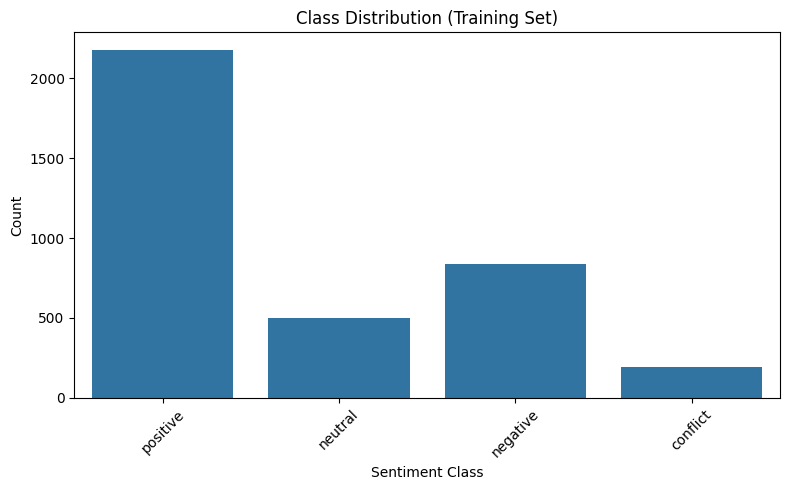

In [11]:
# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='polarity', data=flat_train_df, order=['positive', 'neutral', 'negative', 'conflict'])
plt.title("Class Distribution (Training Set)")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


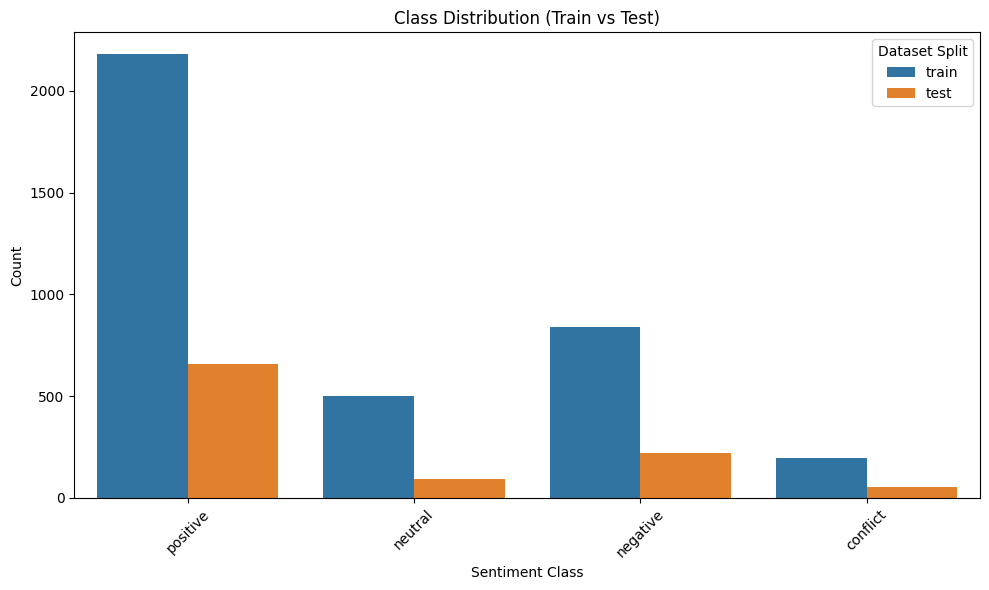

In [12]:
# Compare train and test distribution
flat_train_df['split'] = 'train'
flat_test_df['split'] = 'test'
combined_df = pd.concat([flat_train_df, flat_test_df])

plt.figure(figsize=(10, 6))
sns.countplot(
    data=combined_df,
    x='polarity',
    hue='split',
    order=['positive', 'neutral', 'negative', 'conflict']
)
plt.title("Class Distribution (Train vs Test)")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.legend(title="Dataset Split")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


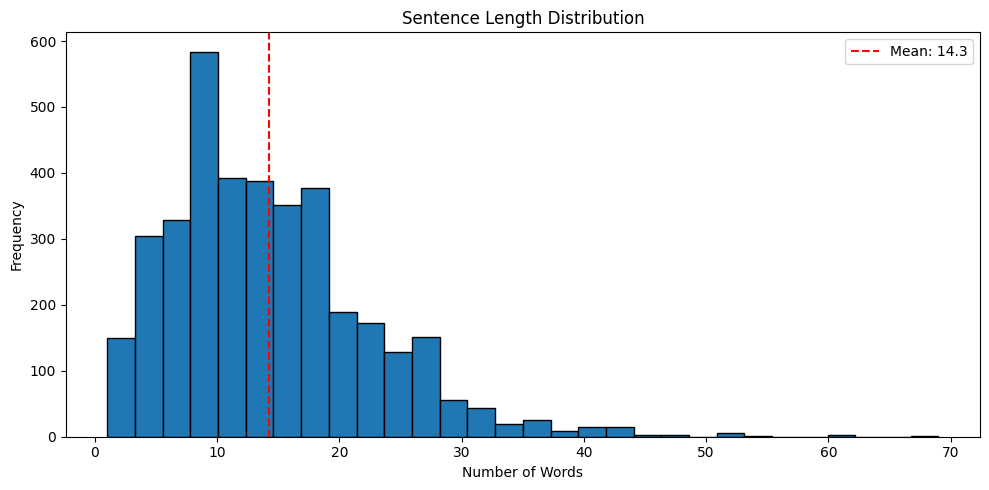

Average sentence length: 14.26 words
Max sentence length: 69 words


In [13]:
# Sentence length distribution
flat_train_df['sentence_length'] = flat_train_df['sentence'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
plt.hist(flat_train_df['sentence_length'], bins=30, edgecolor='black')
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.axvline(flat_train_df['sentence_length'].mean(), color='red', linestyle='--', 
            label=f"Mean: {flat_train_df['sentence_length'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average sentence length: {flat_train_df['sentence_length'].mean():.2f} words")
print(f"Max sentence length: {flat_train_df['sentence_length'].max()} words")


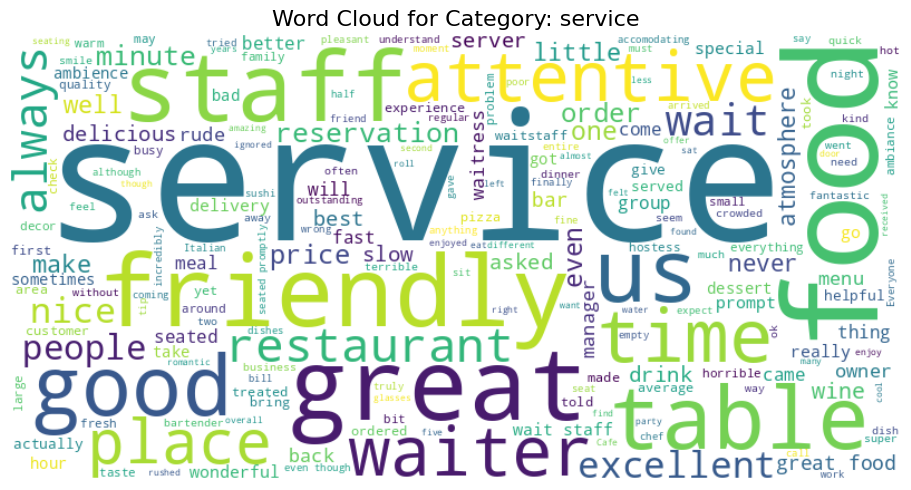

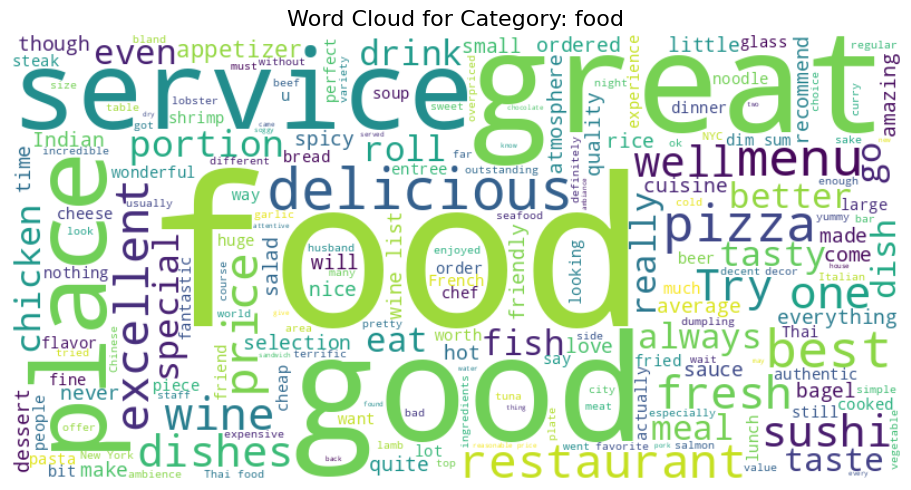

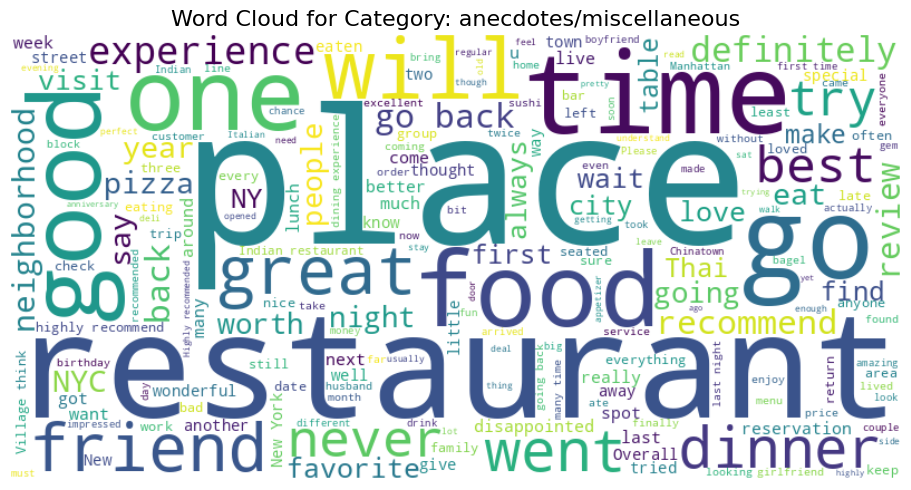

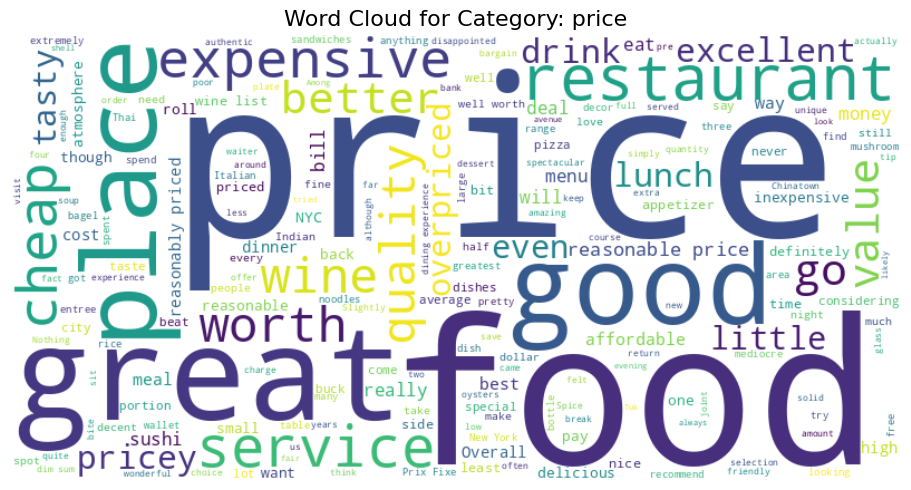

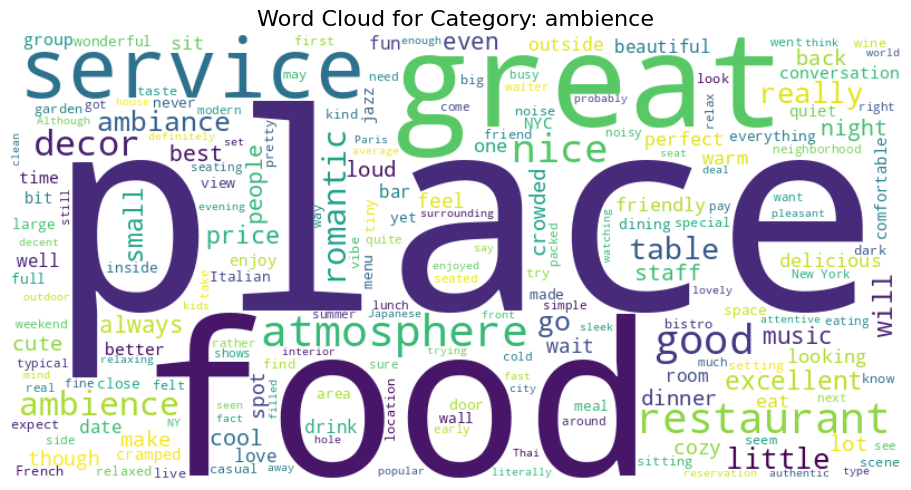

In [14]:
# Word clouds for each category
categories = flat_train_df['category'].unique()

for cat in categories:
    text = " ".join(flat_train_df[flat_train_df['category'] == cat]['sentence'])
    
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Category: {cat}", fontsize=16)
    plt.tight_layout()
    plt.show()


In [15]:
# ============================================================================
# PHASE 2: ABSA MODEL TRAINING (CATEGORY-BASED SENTIMENT CLASSIFICATION)
# ============================================================================

import torch
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import numpy as np


In [16]:
# Prepare data for 3-class classification (positive, negative, neutral)
# Remove 'conflict' samples for cleaner classification

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {0: 'negative', 1: 'neutral', 2: 'positive'}
NUM_LABELS = 3

train_phase2 = flat_train_df[flat_train_df['polarity'].isin(LABEL2ID.keys())].copy()
test_phase2 = flat_test_df[flat_test_df['polarity'].isin(LABEL2ID.keys())].copy()

train_phase2['label'] = train_phase2['polarity'].map(LABEL2ID)
test_phase2['label'] = test_phase2['polarity'].map(LABEL2ID)

print(f"Number of classes: {NUM_LABELS}")
print(f"Training samples (without conflict): {len(train_phase2)}")
print(f"Test samples (without conflict): {len(test_phase2)}")
print("\nLabel distribution in training:")
print(train_phase2['polarity'].value_counts())


Number of classes: 3
Training samples (without conflict): 3518
Test samples (without conflict): 973

Label distribution in training:
polarity
positive    2179
negative     839
neutral      500
Name: count, dtype: int64


In [17]:
# Dataset class for ABSA
class ABSADataset(Dataset):
    """
    Dataset for Aspect-Based Sentiment Analysis
    Input format: [CLS] sentence [SEP] aspect/category [SEP]
    """
    def __init__(self, sentences, aspects, labels, tokenizer, max_length=128):
        self.sentences = sentences
        self.aspects = aspects
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        sentence = str(self.sentences[idx])
        aspect = str(self.aspects[idx])
        label = self.labels[idx]
        
        # Combine sentence and aspect as two segments
        encoded = self.tokenizer(
            sentence,
            aspect,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt',
            return_attention_mask=True
        )
        
        return {
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [18]:
# Load pre-trained model and tokenizer
MODEL_NAME = "bert-base-uncased"  # Can also use "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

print(f"Model loaded: {MODEL_NAME}")
print(f"Number of output classes: {NUM_LABELS}")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: bert-base-uncased
Number of output classes: 3


In [19]:
# Hyperparameters
MAX_LENGTH = 128
BATCH_SIZE = 16
VAL_RATIO = 0.15
RANDOM_STATE = 42
EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

print("=" * 60)
print("HYPERPARAMETERS AND SETTINGS")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max Length: {MAX_LENGTH}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Validation Ratio: {VAL_RATIO}")
print(f"Random State: {RANDOM_STATE}")
print("=" * 60)


HYPERPARAMETERS AND SETTINGS
Model: bert-base-uncased
Batch Size: 16
Max Length: 128
Epochs: 4
Learning Rate: 2e-05
Weight Decay: 0.01
Validation Ratio: 0.15
Random State: 42


In [20]:
# Split training data into train/validation
train_sents, val_sents, train_asps, val_asps, train_lbl, val_lbl = train_test_split(
    train_phase2['sentence'].tolist(),
    train_phase2['category'].tolist(),
    train_phase2['label'].tolist(),
    test_size=VAL_RATIO,
    random_state=RANDOM_STATE,
    stratify=train_phase2['label']
)

# Create datasets
train_dataset = ABSADataset(train_sents, train_asps, train_lbl, tokenizer, max_length=MAX_LENGTH)
val_dataset = ABSADataset(val_sents, val_asps, val_lbl, tokenizer, max_length=MAX_LENGTH)
test_dataset = ABSADataset(
    test_phase2['sentence'].tolist(),
    test_phase2['category'].tolist(),
    test_phase2['label'].tolist(),
    tokenizer,
    max_length=MAX_LENGTH
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=RandomSampler(train_dataset))
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=SequentialSampler(val_dataset))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, sampler=SequentialSampler(test_dataset))

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")


Training batches: 187
Validation batches: 33
Test batches: 61


In [21]:
# Setup training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = base_model.to(device)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


Using device: cuda


In [22]:
# Training loop with validation
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

def compute_accuracy(preds, labels):
    """Calculate accuracy"""
    return (preds == labels).float().mean().item()

print("\nStarting training...")
print("=" * 60)

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    epoch_train_correct = 0
    epoch_train_total = 0
    
    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for batch in train_progress:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        epoch_train_correct += (preds == labels).sum().item()
        epoch_train_total += labels.size(0)
        
        # Update progress bar
        train_progress.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss = epoch_train_loss / len(train_loader)
    train_acc = epoch_train_correct / epoch_train_total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validation phase
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]  ")
        for batch in val_progress:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss_sum += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    
    val_loss = val_loss_sum / len(val_loader)
    val_acc = val_correct / val_total
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 60)

print("\nTraining completed!")



Starting training...


Epoch 1/4 [Val]  : 100%|██████████| 33/33 [00:03<00:00,  8.28it/s]



Epoch 1/4
  Train Loss: 0.6866 | Train Acc: 0.7060
  Val Loss:   0.5518 | Val Acc:   0.7936
------------------------------------------------------------


Epoch 2/4 [Val]  : 100%|██████████| 33/33 [00:04<00:00,  6.77it/s]



Epoch 2/4
  Train Loss: 0.3950 | Train Acc: 0.8532
  Val Loss:   0.4869 | Val Acc:   0.8125
------------------------------------------------------------


Epoch 3/4 [Val]  : 100%|██████████| 33/33 [00:04<00:00,  7.08it/s]



Epoch 3/4
  Train Loss: 0.2337 | Train Acc: 0.9227
  Val Loss:   0.5529 | Val Acc:   0.7936
------------------------------------------------------------


Epoch 4/4 [Val]  : 100%|██████████| 33/33 [00:04<00:00,  7.08it/s]


Epoch 4/4
  Train Loss: 0.1459 | Train Acc: 0.9488
  Val Loss:   0.5629 | Val Acc:   0.8087
------------------------------------------------------------

Training completed!


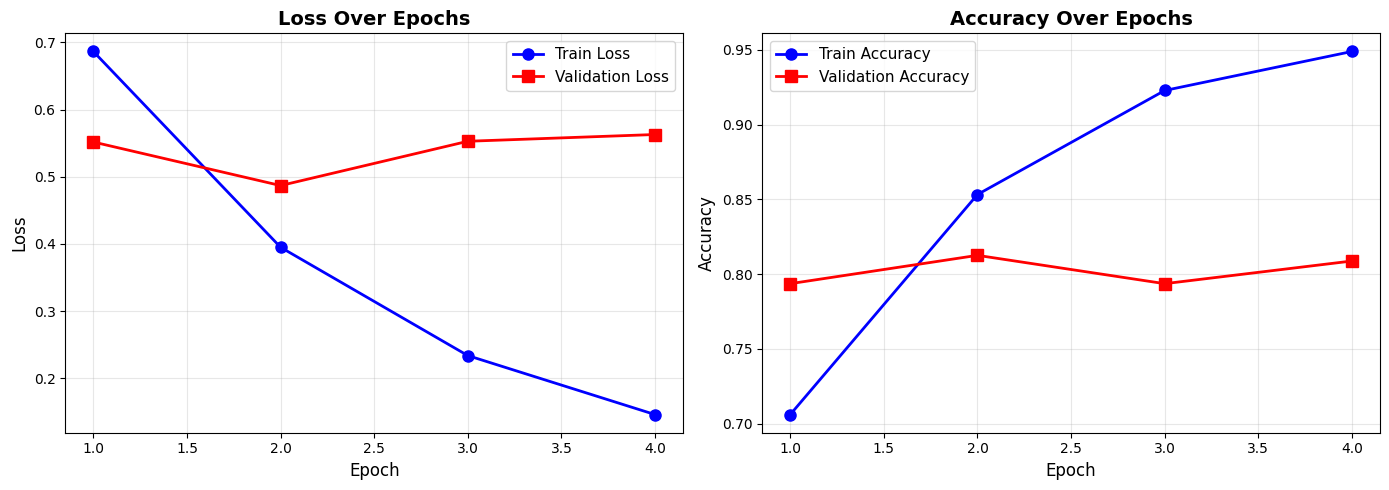

In [23]:
# Plot training history
epochs_range = np.arange(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=8)
ax1.plot(epochs_range, history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=8)
ax2.plot(epochs_range, history['val_acc'], 'r-s', label='Validation Accuracy', linewidth=2, markersize=8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [24]:
# Final evaluation on test set
print("\nEvaluating on test set...")
model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = outputs.logits.argmax(dim=1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
print(f"\n{'='*60}")
print(f"FINAL TEST ACCURACY: {test_accuracy:.4f} ({test_correct}/{test_total})")
print(f"{'='*60}")



Evaluating on test set...


Testing: 100%|██████████| 61/61 [00:08<00:00,  7.12it/s]


FINAL TEST ACCURACY: 0.8684 (845/973)



Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.79      0.81       222
     neutral       0.57      0.73      0.64        94
    positive       0.93      0.91      0.92       657

    accuracy                           0.87       973
   macro avg       0.78      0.81      0.79       973
weighted avg       0.88      0.87      0.87       973



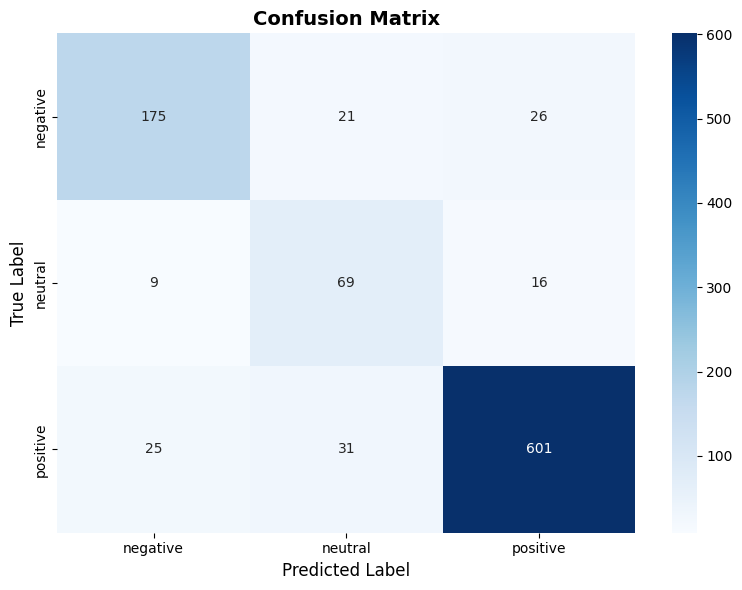

In [25]:
# Detailed classification report
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['negative', 'neutral', 'positive']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


In [26]:
# Save the trained model
MODEL_SAVE_PATH = "absa_category_model"
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to: absa_category_model


In [27]:
# ============================================================================
# PHASE 3: ASPECT TERM EXTRACTION (PHASE A)
# ============================================================================
"""
Phase A: Given a sentence, identify and extract aspect terms
This is a sequence labeling task (NER-like) using BIO tagging scheme:
- B-ASP: Beginning of aspect term
- I-ASP: Inside aspect term
- O: Outside (not an aspect term)
"""

print("\n" + "="*60)
print("PHASE 3: ASPECT TERM EXTRACTION")
print("="*60)



PHASE 3: ASPECT TERM EXTRACTION


In [ ]:
import os

# Prepare data for aspect term extraction
def prepare_aspect_extraction_data(csv_path):
    """
    Prepare data for aspect term extraction (sequence labeling)
    Returns: List of (sentence, aspect_term, from, to) tuples
    """
    df = pd.read_csv(csv_path)
    # Group by sentence ID to get all aspects for each sentence
    grouped = df.groupby('id')
    
    data = []
    for sent_id, group in grouped:
        sentence = group.iloc[0]['Sentence']
        aspects = []
        for _, row in group.iterrows():
            aspects.append({
                'term': row['Aspect Term'],
                'from': row['from'],
                'to': row['to'],
                'polarity': row['polarity']
            })
        data.append({
            'id': sent_id,
            'sentence': sentence,
            'aspects': aspects
        })
    return data



BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
DATA_DIR = os.path.join(os.path.dirname(BASE_DIR), 'data')

# Load training data
restaurants_train_data = prepare_aspect_extraction_data(os.path.join(DATA_DIR, 'Restaurants_Train_v2.csv'))
laptops_train_data = prepare_aspect_extraction_data(os.path.join(DATA_DIR, 'Laptop_Train_v2.csv'))

print(f"Restaurant training samples: {len(restaurants_train_data)}")
print(f"Laptop training samples: {len(laptops_train_data)}")


Restaurant training samples: 2021
Laptop training samples: 1488


In [34]:
# Create BIO tags for sequence labeling
def create_bio_tags(sentence, aspects):
    """
    Create BIO tags for a sentence given its aspect terms
    """
    words = sentence.split()
    tags = ['O'] * len(words)
    
    for aspect in aspects:
        if aspect['term'] == 'NULL':
            continue
            
        term = aspect['term']
        start_char = aspect['from']
        end_char = aspect['to']
        
        # Find word positions corresponding to character positions
        current_pos = 0
        word_positions = []
        for i, word in enumerate(words):
            word_start = current_pos
            word_end = current_pos + len(word)
            word_positions.append((word_start, word_end))
            current_pos = word_end + 1  # +1 for space
        
        # Tag words that overlap with aspect term
        for i, (w_start, w_end) in enumerate(word_positions):
            # Check if word overlaps with aspect span
            if w_start < end_char and w_end > start_char:
                if tags[i] == 'O':  # Only tag if not already tagged
                    if w_start >= start_char:  # Word starts within or after aspect
                        if i > 0 and tags[i-1] in ['B-ASP', 'I-ASP']:
                            tags[i] = 'I-ASP'
                        else:
                            tags[i] = 'B-ASP'
                    else:  # Word starts before aspect but overlaps
                        tags[i] = 'B-ASP'
    
    return words, tags

# Test BIO tagging
sample = restaurants_train_data[0]
words, tags = create_bio_tags(sample['sentence'], sample['aspects'])
print("\nSample BIO tagging:")
print(f"Sentence: {sample['sentence']}")
print(f"Aspects: {[a['term'] for a in sample['aspects']]}")
print("\nWord-Tag pairs:")
for word, tag in zip(words, tags):
    if tag != 'O':
        print(f"  {word:20s} -> {tag}")



Sample BIO tagging:
Sentence: The staff isn't the friendliest or most competent, and I am stickler for service, but everything else about this place makes up for it.
Aspects: ['staff', 'service']

Word-Tag pairs:
  staff                -> B-ASP
  service,             -> B-ASP


In [35]:
# Prepare dataset for token classification
def prepare_token_classification_data(data_list):
    """Convert data to format for token classification"""
    sentences = []
    tags_list = []
    
    for item in data_list:
        words, tags = create_bio_tags(item['sentence'], item['aspects'])
        sentences.append(words)
        tags_list.append(tags)
    
    return sentences, tags_list

rest_train_sents, rest_train_tags = prepare_token_classification_data(restaurants_train_data)
laptop_train_sents, laptop_train_tags = prepare_token_classification_data(laptops_train_data)

print(f"\nRestaurant sentences: {len(rest_train_sents)}")
print(f"Laptop sentences: {len(laptop_train_sents)}")



Restaurant sentences: 2021
Laptop sentences: 1488


In [36]:
# Token classification dataset
class TokenClassificationDataset(Dataset):
    """Dataset for aspect term extraction (token classification)"""
    
    def __init__(self, sentences, tags, tokenizer, label2id, max_length=128):
        self.sentences = sentences
        self.tags = tags
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length
    
    def __len__(self):
        return len(self.sentences)
    
    def __getitem__(self, idx):
        words = self.sentences[idx]
        tags = self.tags[idx]
        
        # Tokenize and align labels
        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        # Align labels with tokens
        labels = []
        word_ids = encoding.word_ids(batch_index=0)
        previous_word_idx = None
        
        for word_idx in word_ids:
            if word_idx is None:
                labels.append(-100)  # Special tokens
            elif word_idx != previous_word_idx:
                labels.append(self.label2id[tags[word_idx]])
            else:
                labels.append(-100)  # Subword tokens
            previous_word_idx = word_idx
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(labels, dtype=torch.long)
        }


In [37]:
# Setup for token classification
from transformers import AutoModelForTokenClassification

TAG2ID = {'O': 0, 'B-ASP': 1, 'I-ASP': 2}
ID2TAG = {0: 'O', 1: 'B-ASP', 2: 'I-ASP'}

# Train on restaurants data (you can combine with laptops if needed)
ner_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
ner_model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(TAG2ID)
)

# Create dataset
ner_train_dataset = TokenClassificationDataset(
    rest_train_sents,
    rest_train_tags,
    ner_tokenizer,
    TAG2ID,
    max_length=128
)

ner_train_loader = DataLoader(ner_train_dataset, batch_size=16, shuffle=True)

print(f"NER training batches: {len(ner_train_loader)}")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

NER training batches: 127


In [38]:
# Train aspect extraction model
NER_EPOCHS = 3
NER_LR = 3e-5

ner_model = ner_model.to(device)
ner_optimizer = AdamW(ner_model.parameters(), lr=NER_LR)

print("\nTraining aspect extraction model...")
print("="*60)

for epoch in range(NER_EPOCHS):
    ner_model.train()
    epoch_loss = 0.0
    
    progress = tqdm(ner_train_loader, desc=f"NER Epoch {epoch+1}/{NER_EPOCHS}")
    for batch in progress:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        ner_optimizer.zero_grad()
        outputs = ner_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        ner_optimizer.step()
        
        epoch_loss += loss.item()
        progress.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = epoch_loss / len(ner_train_loader)
    print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")

# Save NER model
NER_MODEL_PATH = "aspect_extraction_model"
ner_model.save_pretrained(NER_MODEL_PATH)
ner_tokenizer.save_pretrained(NER_MODEL_PATH)
print(f"\nAspect extraction model saved to: {NER_MODEL_PATH}")



Training aspect extraction model...


NER Epoch 1/3: 100%|██████████| 127/127 [00:46<00:00,  2.75it/s, loss=0.1493]


Epoch 1 - Average Loss: 0.2156


NER Epoch 2/3: 100%|██████████| 127/127 [00:49<00:00,  2.56it/s, loss=0.0602]


Epoch 2 - Average Loss: 0.0743


NER Epoch 3/3: 100%|██████████| 127/127 [00:48<00:00,  2.64it/s, loss=0.0046]

Epoch 3 - Average Loss: 0.0328


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Aspect extraction model saved to: aspect_extraction_model


In [39]:
# Function to extract aspects from new sentences
def extract_aspects(sentence, model, tokenizer, device, id2tag):
    """Extract aspect terms from a sentence"""
    model.eval()
    
    words = sentence.split()
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits.argmax(dim=-1)
    
    # Align predictions with words
    word_ids = encoding.word_ids(batch_index=0)
    predicted_tags = []
    previous_word_idx = None
    
    for word_idx, pred in zip(word_ids, predictions[0]):
        if word_idx is not None and word_idx != previous_word_idx:
            predicted_tags.append(id2tag[pred.item()])
        previous_word_idx = word_idx
    
    # Extract aspect terms
    aspects = []
    current_aspect = []
    
    for word, tag in zip(words, predicted_tags):
        if tag == 'B-ASP':
            if current_aspect:
                aspects.append(' '.join(current_aspect))
            current_aspect = [word]
        elif tag == 'I-ASP':
            current_aspect.append(word)
        else:
            if current_aspect:
                aspects.append(' '.join(current_aspect))
                current_aspect = []
    
    if current_aspect:
        aspects.append(' '.join(current_aspect))
    
    return aspects

# Test aspect extraction
test_sentence = "The food was delicious but the service was slow."
extracted = extract_aspects(test_sentence, ner_model, ner_tokenizer, device, ID2TAG)
print(f"\nTest sentence: {test_sentence}")
print(f"Extracted aspects: {extracted}")



Test sentence: The food was delicious but the service was slow.
Extracted aspects: ['food', 'service']


In [40]:
# ============================================================================
# PHASE 4: SENTIMENT CLASSIFICATION FOR EXTRACTED ASPECTS (PHASE B)
# ============================================================================
"""
Phase B: Given a sentence and an aspect term, classify the sentiment polarity
We use the trained ABSA model from Phase 2
"""

print("\n" + "="*60)
print("PHASE 4: SENTIMENT CLASSIFICATION FOR ASPECTS")
print("="*60)



PHASE 4: SENTIMENT CLASSIFICATION FOR ASPECTS


In [43]:
# Load Phase A test data
def load_phase_a_test_data(csv_path):
    """Load test data for Phase A (sentences only)"""
    df = pd.read_csv(csv_path)
    return df

rest_test_phaseA = load_phase_a_test_data(os.path.join(DATA_DIR, 'Restaurants_Test_Data_PhaseA.csv'))
laptop_test_phaseA = load_phase_a_test_data(os.path.join(DATA_DIR, 'Laptops_Test_Data_PhaseA.csv'))

print(f"Restaurant Phase A test: {len(rest_test_phaseA)} sentences")
print(f"Laptop Phase A test: {len(laptop_test_phaseA)} sentences")
print("\nSample:")
print(rest_test_phaseA.head())


Restaurant Phase A test: 800 sentences
Laptop Phase A test: 800 sentences

Sample:
                  id                                           Sentence
0  32897564#894393#2                    The bread is top notch as well.
1  33070600#670328#0  I have to say they have one of the fastest del...
2  33070600#670328#2        Food is always fresh and hot- ready to eat!
3  36244464#949326#5      Did I mention that the coffee is OUTSTANDING?
4  32894246#870052#0  Certainly not the best sushi in New York, howe...


In [44]:
# Process Phase A: Extract aspects from test sentences
def process_phase_a(test_df, ner_model, ner_tokenizer, device, id2tag):
    """
    Phase A: Extract aspect terms from sentences
    Returns DataFrame with extracted aspects
    """
    results = []
    
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Phase A - Extracting aspects"):
        sent_id = row['id']
        sentence = row['Sentence']
        
        # Extract aspects
        aspects = extract_aspects(sentence, ner_model, ner_tokenizer, device, id2tag)
        
        if aspects:
            for aspect in aspects:
                results.append({
                    'id': sent_id,
                    'sentence': sentence,
                    'aspect': aspect
                })
        else:
            # If no aspects found, add a placeholder
            results.append({
                'id': sent_id,
                'sentence': sentence,
                'aspect': 'NULL'
            })
    
    return pd.DataFrame(results)

# Run Phase A on test data
rest_phaseA_results = process_phase_a(rest_test_phaseA, ner_model, ner_tokenizer, device, ID2TAG)
laptop_phaseA_results = process_phase_a(laptop_test_phaseA, ner_model, ner_tokenizer, device, ID2TAG)

print(f"\nRestaurant Phase A results: {len(rest_phaseA_results)} aspect mentions")
print(f"Laptop Phase A results: {len(laptop_phaseA_results)} aspect mentions")
print("\nSample results:")
print(rest_phaseA_results.head(10))


Phase A - Extracting aspects: 100%|██████████| 800/800 [00:07<00:00, 113.57it/s]


Restaurant Phase A results: 1406 aspect mentions
Laptop Phase A results: 1214 aspect mentions

Sample results:
                  id                                           sentence  \
0  32897564#894393#2                    The bread is top notch as well.   
1  33070600#670328#0  I have to say they have one of the fastest del...   
2  33070600#670328#2        Food is always fresh and hot- ready to eat!   
3  36244464#949326#5      Did I mention that the coffee is OUTSTANDING?   
4  32894246#870052#0  Certainly not the best sushi in New York, howe...   
5  32894246#870052#0  Certainly not the best sushi in New York, howe...   
6  32894246#870052#1  I trust the people at Go Sushi, it never disap...   
7  32894246#870052#2  Straight-forward, no surprises, very decent Ja...   
8  35390182#756337#4           BEST spicy tuna roll, great asian salad.   
9  35390182#756337#4           BEST spicy tuna roll, great asian salad.   

             aspect  
0             bread  
1    delivery time

In [45]:
# Process Phase B: Classify sentiment for extracted aspects
def predict_sentiment(sentence, aspect, model, tokenizer, device, id2label):
    """Predict sentiment polarity for a sentence-aspect pair"""
    model.eval()
    
    encoding = tokenizer(
        sentence,
        aspect,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        prediction = outputs.logits.argmax(dim=-1).item()
    
    return id2label[prediction]

def process_phase_b(phaseA_results, sentiment_model, sentiment_tokenizer, device, id2label):
    """
    Phase B: Classify sentiment for extracted aspects
    """
    results = []
    
    for _, row in tqdm(phaseA_results.iterrows(), total=len(phaseA_results), 
                      desc="Phase B - Classifying sentiment"):
        sent_id = row['id']
        sentence = row['sentence']
        aspect = row['aspect']
        
        # Predict sentiment
        if aspect != 'NULL':
            polarity = predict_sentiment(sentence, aspect, sentiment_model, 
                                       sentiment_tokenizer, device, id2label)
        else:
            polarity = 'neutral'  # Default for NULL aspects
        
        results.append({
            'id': sent_id,
            'sentence': sentence,
            'aspect': aspect,
            'polarity': polarity
        })
    
    return pd.DataFrame(results)

# Run Phase B
print("\nRunning Phase B on extracted aspects...")
rest_phaseB_results = process_phase_b(rest_phaseA_results, model, tokenizer, device, ID2LABEL)
laptop_phaseB_results = process_phase_b(laptop_phaseA_results, model, tokenizer, device, ID2LABEL)

print(f"\nRestaurant Phase B complete: {len(rest_phaseB_results)} predictions")
print(f"Laptop Phase B complete: {len(laptop_phaseB_results)} predictions")



Running Phase B on extracted aspects...


Phase B - Classifying sentiment: 100%|██████████| 1214/1214 [00:11<00:00, 103.13it/s]


Restaurant Phase B complete: 1406 predictions
Laptop Phase B complete: 1214 predictions


In [46]:
# Display results summary
print("\n" + "="*60)
print("PHASE B RESULTS SUMMARY")
print("="*60)

print("\nRestaurants - Sentiment Distribution:")
print(rest_phaseB_results['polarity'].value_counts())

print("\nLaptops - Sentiment Distribution:")
print(laptop_phaseB_results['polarity'].value_counts())

print("\nSample predictions (Restaurants):")
print(rest_phaseB_results.head(10))

print("\nSample predictions (Laptops):")
print(laptop_phaseB_results.head(10))



PHASE B RESULTS SUMMARY

Restaurants - Sentiment Distribution:
polarity
positive    901
negative    288
neutral     217
Name: count, dtype: int64

Laptops - Sentiment Distribution:
polarity
positive    546
negative    426
neutral     242
Name: count, dtype: int64

Sample predictions (Restaurants):
                  id                                           sentence  \
0  32897564#894393#2                    The bread is top notch as well.   
1  33070600#670328#0  I have to say they have one of the fastest del...   
2  33070600#670328#2        Food is always fresh and hot- ready to eat!   
3  36244464#949326#5      Did I mention that the coffee is OUTSTANDING?   
4  32894246#870052#0  Certainly not the best sushi in New York, howe...   
5  32894246#870052#0  Certainly not the best sushi in New York, howe...   
6  32894246#870052#1  I trust the people at Go Sushi, it never disap...   
7  32894246#870052#2  Straight-forward, no surprises, very decent Ja...   
8  35390182#756337#4     

In [47]:
# Save Phase B results
rest_phaseB_results.to_csv('restaurants_phaseB_predictions.csv', index=False)
laptop_phaseB_results.to_csv('laptops_phaseB_predictions.csv', index=False)

print("\nResults saved:")
print("  - restaurants_phaseB_predictions.csv")
print("  - laptops_phaseB_predictions.csv")



Results saved:
  - restaurants_phaseB_predictions.csv
  - laptops_phaseB_predictions.csv


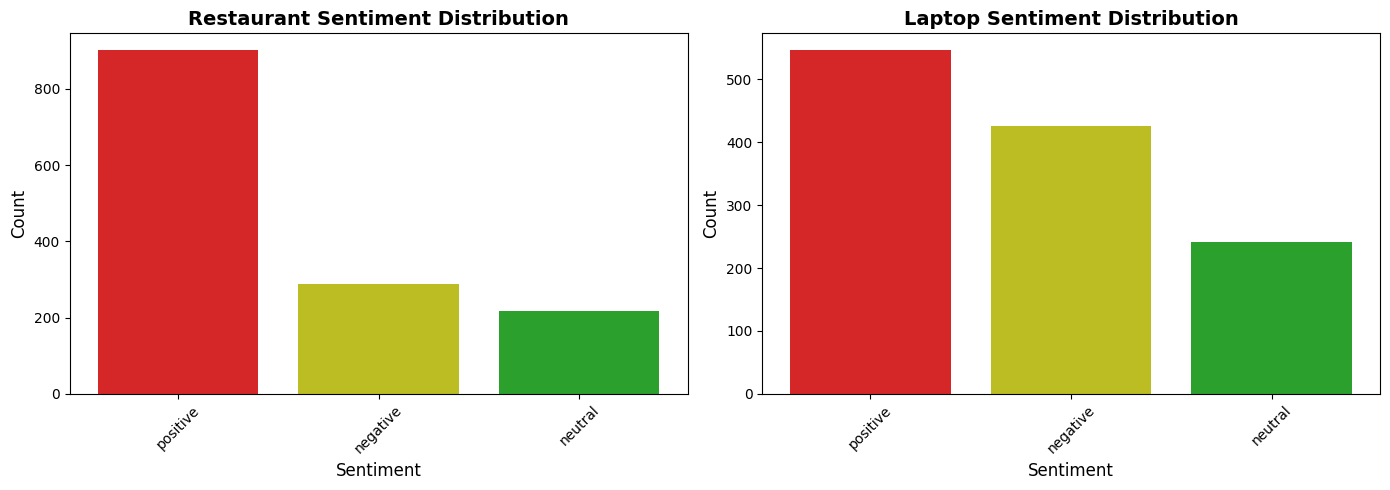

In [48]:
# Visualize Phase B results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Restaurants
rest_counts = rest_phaseB_results['polarity'].value_counts()
ax1.bar(rest_counts.index, rest_counts.values, color=['#d62728', '#bcbd22', '#2ca02c'])
ax1.set_title('Restaurant Sentiment Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Laptops
laptop_counts = laptop_phaseB_results['polarity'].value_counts()
ax2.bar(laptop_counts.index, laptop_counts.values, color=['#d62728', '#bcbd22', '#2ca02c'])
ax2.set_title('Laptop Sentiment Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sentiment', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [49]:
# ============================================================================
# COMPLETE PIPELINE DEMONSTRATION
# ============================================================================
"""
Demonstrate the complete pipeline: 
Input sentence -> Extract aspects -> Classify sentiment
"""

def complete_absa_pipeline(sentence, ner_model, ner_tokenizer, sentiment_model, 
                          sentiment_tokenizer, device, id2tag, id2label):
    """
    Complete ABSA pipeline:
    1. Extract aspect terms from sentence
    2. Classify sentiment for each aspect
    """
    # Step 1: Extract aspects
    aspects = extract_aspects(sentence, ner_model, ner_tokenizer, device, id2tag)
    
    # Step 2: Classify sentiment for each aspect
    results = []
    for aspect in aspects:
        polarity = predict_sentiment(sentence, aspect, sentiment_model, 
                                    sentiment_tokenizer, device, id2label)
        results.append({
            'aspect': aspect,
            'polarity': polarity
        })
    
    return results

# Test the complete pipeline
test_sentences = [
    "The food was delicious but the service was terrible.",
    "Great ambiance and friendly staff, but the prices are too high.",
    "The battery life is excellent and the screen is beautiful.",
    "Poor performance and the keyboard is uncomfortable."
]

print("\n" + "="*60)
print("COMPLETE ABSA PIPELINE DEMONSTRATION")
print("="*60)

for sent in test_sentences:
    print(f"\nSentence: {sent}")
    results = complete_absa_pipeline(sent, ner_model, ner_tokenizer, model, 
                                    tokenizer, device, ID2TAG, ID2LABEL)
    
    if results:
        print("Aspect-Sentiment pairs:")
        for r in results:
            print(f"  - {r['aspect']:25s} -> {r['polarity']}")
    else:
        print("  No aspects detected")

print("\n" + "="*60)
print("PROJECT COMPLETE!")
print("="*60)


COMPLETE ABSA PIPELINE DEMONSTRATION

Sentence: The food was delicious but the service was terrible.
Aspect-Sentiment pairs:
  - food                      -> negative
  - service                   -> negative

Sentence: Great ambiance and friendly staff, but the prices are too high.
Aspect-Sentiment pairs:
  - ambiance                  -> positive
  - staff,                    -> positive
  - prices                    -> negative

Sentence: The battery life is excellent and the screen is beautiful.
Aspect-Sentiment pairs:
  - battery life              -> positive
  - screen                    -> positive

Sentence: Poor performance and the keyboard is uncomfortable.
Aspect-Sentiment pairs:
  - performance               -> negative
  - keyboard                  -> negative

PROJECT COMPLETE!
